# 04. Entrenamiento — Fase 4

Modelo de **incidencia** de cáncer de mama (predice nuevos casos en T+1 sobre población sin
diagnóstico en T). Desbalance extremo (~2.300:1, event rate 0,043%). **58 features**
(`tiene_avicena` excluida a priori por sesgo de vigilancia — redundante con `n_consultas_T`;
ver Fase 5).

**Técnicas aplicadas:**
- **GroupKFold(5) por `key`** — la misma paciente puede ser negativa en un par y positiva en
  otro (2021→2022 vs 2022→2023); evita que esté en train y validación del mismo fold.
- **SMOTE + undersampling** del majority, **solo dentro del train de cada fold** (imblearn
  Pipeline → sin fuga hacia el fold de validación).
- **class_weight / scale_pos_weight** como alternativa a SMOTE.
- **Predicciones out-of-fold (OOF)** para métricas honestas.
- **Optimización de umbral** (F2, prioriza recall) y **recall@top-k** (operación de tamización).
- **Dos variantes de imputación:** lineal sobre `_impute` (mediana), árboles sobre `_native`
  (NaN nativo).
- **Validación temporal final:** refit en train completo, evaluación en el par 2023→2024.

**Métrica primaria:** AUC-PR (área bajo precision-recall) — informativa bajo desbalance extremo,
a diferencia de AUC-ROC. Secundaria: Recall (minimizar falsos negativos).

> **Reproducibilidad:** las predicciones OOF y las métricas de este notebook se **cargan** de los
> artefactos del pipeline (`oof_predicciones.npz`, `_resultados_sin_avicena.json`). Las
> definiciones de modelo se mantienen como documentación de la configuración entrenada.


In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve)
import lightgbm as lgb
import xgboost as xgb

B = "bases"
RNG = 42
DROP = ['tiene_avicena']   # excluida a priori (sesgo de vigilancia)

RES = json.load(open(f"{B}/_resultados_sin_avicena.json", encoding="utf-8"))
print("Artefactos canónicos:", RES['n_features'], "features |",
      "eliminadas:", RES['features_eliminadas'])


Artefactos canónicos: 58 features | eliminadas: ['tiene_avicena']


In [2]:
# Cargar ambas variantes (mismas filas/orden/columnas; difieren solo en imputables)
imp_tr = pd.read_parquet(f"{B}/prediccion_mama_train_impute.parquet")
imp_va = pd.read_parquet(f"{B}/prediccion_mama_val_impute.parquet")

FEAT = [c for c in imp_tr.columns if c not in ('key', 'label', *DROP)]
y_tr = imp_tr['label'].values.astype(int)
g_tr = imp_tr['key'].values
y_va = imp_va['label'].values.astype(int)

assert len(FEAT) == RES['n_features'], (len(FEAT), RES['n_features'])
print(f"train {imp_tr.shape[0]:,} filas pos {y_tr.sum()} ({y_tr.mean()*100:.4f}%) | "
      f"val {imp_va.shape[0]:,} filas pos {y_va.sum()} ({y_va.mean()*100:.4f}%)")
print(f"features: {len(FEAT)} (tiene_avicena excluida) | "
      f"grupos únicos (key) en train: {pd.Series(g_tr).nunique():,}")
print(f"ratio neg/pos train: {(y_tr==0).sum()/(y_tr==1).sum():.0f}:1")


train 4,286,080 filas pos 1857 (0.0433%) | val 2,410,807 filas pos 993 (0.0412%)


features: 58 (tiene_avicena excluida) | grupos únicos (key) en train: 2,469,699
ratio neg/pos train: 2307:1


## 1. Métricas y framework OOF

Las predicciones out-of-fold se obtuvieron con GroupKFold(5) por `key` (el `resampler`
SMOTE+undersampling se aplicó **dentro** del train de cada fold, sin fuga). Aquí se recargan
para calcular las métricas honestas.


In [3]:
def metrics_at_best_f2(y, p, beta=2.0):
    prec, rec, thr = precision_recall_curve(y, p)
    f2 = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)
    i = int(np.nanargmax(f2[:-1])) if len(thr) > 0 else 0
    return {'thr': float(thr[i]), 'recall': float(rec[i]),
            'precision': float(prec[i]), 'f2': float(f2[i])}

def recall_at_topk(y, p, frac):
    k = max(1, int(len(p) * frac))
    idx = np.argpartition(-p, k)[:k]
    return float(y[idx].sum() / y.sum())

def summarize(y, p, name):
    m = {'modelo': name,
         'AUC_PR': float(average_precision_score(y, p)),
         'AUC_ROC': float(roc_auc_score(y, p))}
    m.update(metrics_at_best_f2(y, p))
    for f in (0.005, 0.01, 0.05, 0.10):
        m[f'recall@top{f*100:.1f}%'] = recall_at_topk(y, p, f)
    return m


## 2. Modelos comparados en Fase 4

Cinco configuraciones de hiperparámetros fijos (los baselines; el tuning con Optuna es Fase 5).

| Modelo | Variante | Desbalance |
|--------|----------|-----------|
| LR-balanced | impute | class_weight |
| LR-SMOTE | impute | SMOTE+under |
| LightGBM-spw | native | scale_pos_weight |
| XGBoost-spw | native | scale_pos_weight |
| LightGBM-SMOTE | impute | SMOTE+under |

`under 0.05 → SMOTE 0.5`: submuestrea el majority a 20× el minority, luego SMOTE eleva el
minority a la mitad del majority (≈3:1 final). Mantiene el set tratable (evita sobre-interpolar
~1.857 positivos a cientos de miles).


## 3. Validación cruzada (OOF) — métricas honestas

Se cargan las predicciones OOF (`oof_predicciones.npz`, una columna por modelo) y se resumen.


In [4]:
npz = np.load(f"{B}/oof_predicciones.npz")
y_oof = npz['y_train']
assert np.array_equal(y_oof, y_tr), "y_train del npz no coincide con el train cargado"

oof = {
    'LR-balanced':    npz['LR_balanced'],
    'LR-SMOTE':       npz['LR_SMOTE'],
    'LightGBM-spw':   npz['LightGBM_spw'],
    'XGBoost-spw':    npz['XGBoost_spw'],
    'LightGBM-SMOTE': npz['LightGBM_SMOTE'],
}
rows = [summarize(y_tr, p, name) for name, p in oof.items()]
cv = pd.DataFrame(rows).set_index('modelo').sort_values('AUC_PR', ascending=False)
pd.set_option('display.width', 200, 'display.max_columns', 30)
print("=== Comparación OOF (ordenado por AUC-PR) ===")
print(cv.to_string(float_format='{:.4f}'.format))


=== Comparación OOF (ordenado por AUC-PR) ===
                AUC_PR  AUC_ROC    thr  recall  precision     f2  recall@top0.5%  recall@top1.0%  recall@top5.0%  recall@top10.0%
modelo                                                                                                                           
LightGBM-SMOTE  0.0273   0.9056 0.8287  0.1637     0.0547 0.1171          0.2628          0.3328          0.5687           0.6861
XGBoost-spw     0.0264   0.8901 0.9706  0.1282     0.0777 0.1134          0.2429          0.3032          0.5261           0.6629
LR-SMOTE        0.0102   0.8872 0.9935  0.1287     0.0373 0.0863          0.1966          0.2553          0.5105           0.6581
LR-balanced     0.0021   0.8160 1.0000  0.2176     0.0036 0.0168          0.0156          0.0598          0.3382           0.5202
LightGBM-spw    0.0011   0.7069 1.0000  0.6570     0.0014 0.0069          0.0113          0.0242          0.1454           0.3150


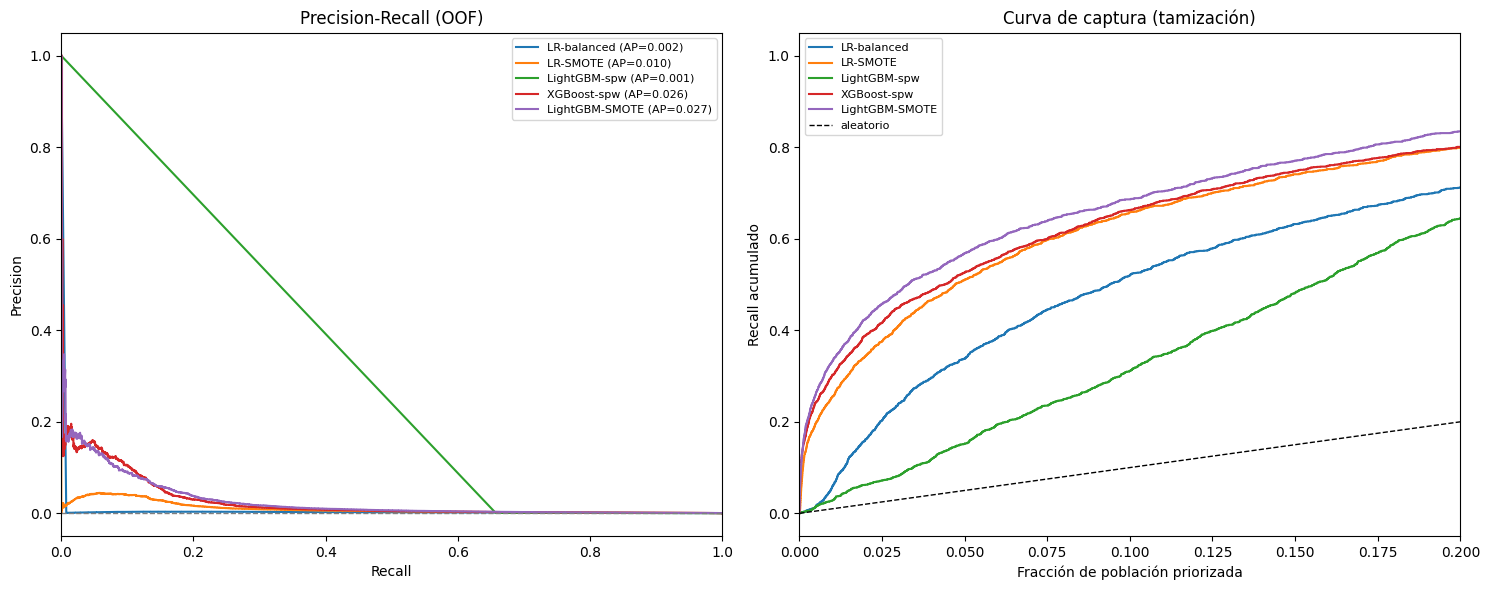

In [5]:
# Curvas Precision-Recall OOF + curva de captura (tamización)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for name, p in oof.items():
    prec, rec, _ = precision_recall_curve(y_tr, p)
    ax[0].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_tr,p):.3f})")
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].set_title('Precision-Recall (OOF)')
ax[0].legend(fontsize=8); ax[0].set_xlim(0, 1)
ax[0].axhline(y_tr.mean(), ls='--', c='gray', lw=1)

for name, p in oof.items():
    order = np.argsort(-p)
    cap = np.cumsum(y_tr[order]) / y_tr.sum()
    frac = np.arange(1, len(p)+1) / len(p)
    ax[1].plot(frac, cap, label=name)
ax[1].plot([0, 1], [0, 1], 'k--', lw=1, label='aleatorio')
ax[1].set_xlabel('Fracción de población priorizada'); ax[1].set_ylabel('Recall acumulado')
ax[1].set_title('Curva de captura (tamización)'); ax[1].legend(fontsize=8)
ax[1].set_xlim(0, 0.2)  # foco en top 20%
plt.tight_layout(); plt.show()


## 4. Evaluación en validación temporal (par 2023→2024)

El test honesto del modelo prospectivo: entrenar con todo el train (2021→2022 + 2022→2023) y
evaluar en un año futuro no visto. Las métricas canónicas se cargan del consolidado del pipeline.


In [6]:
val = pd.DataFrame(RES['fase4']['validacion']).set_index('modelo').sort_values('AUC_PR', ascending=False)
print("=== Validación 2023→2024 (ordenado por AUC-PR) ===")
print(val.to_string(float_format='{:.4f}'.format))


=== Validación 2023→2024 (ordenado por AUC-PR) ===
                AUC_PR  AUC_ROC    thr  recall  precision     f2  recall@top0.5%  recall@top1.0%  recall@top5.0%  recall@top10.0%
modelo                                                                                                                           
LightGBM-SMOTE  0.0313   0.8943 0.9408  0.1269     0.1010 0.1207          0.2548          0.3192          0.5529           0.6788
XGBoost-spw     0.0308   0.8779 0.9624  0.1571     0.0560 0.1154          0.2447          0.3132          0.5358           0.6375
LR-SMOTE        0.0099   0.8769 0.9951  0.1249     0.0391 0.0867          0.2075          0.2659          0.4854           0.6314
LR-balanced     0.0022   0.8250 1.0000  0.1873     0.0040 0.0184          0.0121          0.0493          0.3646           0.5277
LightGBM-spw    0.0010   0.6968 1.0000  0.5579     0.0015 0.0075          0.0161          0.0302          0.1772           0.3756


## 5. Modelo ganador de Fase 4

Se selecciona por AUC-PR en validación. La importancia/SHAP y el tuning quedan para Fase 5.


Modelo ganador Fase 4 (AUC-PR val): LightGBM-SMOTE
  AUC-PR val: 0.0313 | AUC-ROC: 0.894
  recall@top1%: 0.3192 | top5%: 0.5529 | top10%: 0.6788


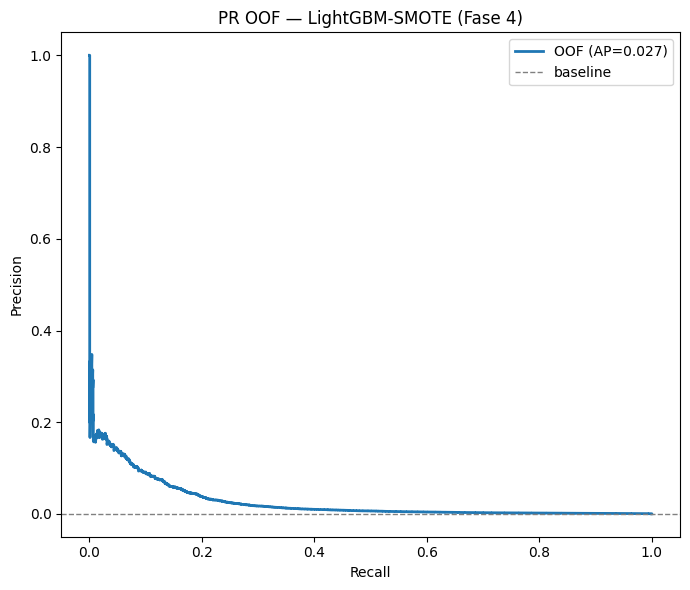

In [7]:
best_name = RES['fase4']['ganador']
row = val.loc[best_name]
print("Modelo ganador Fase 4 (AUC-PR val):", best_name)
print(f"  AUC-PR val: {row['AUC_PR']:.4f} | AUC-ROC: {row['AUC_ROC']:.3f}")
print(f"  recall@top1%: {row['recall@top1.0%']:.4f} | "
      f"top5%: {row['recall@top5.0%']:.4f} | top10%: {row['recall@top10.0%']:.4f}")

# Curva PR OOF del ganador
prec, rec, _ = precision_recall_curve(y_tr, oof[best_name])
plt.figure(figsize=(7, 6))
plt.plot(rec, prec, lw=2, label=f"OOF (AP={average_precision_score(y_tr,oof[best_name]):.3f})")
plt.axhline(y_tr.mean(), ls='--', c='gray', lw=1, label='baseline')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'PR OOF — {best_name} (Fase 4)'); plt.legend(); plt.tight_layout(); plt.show()


## 6. Artefactos

Producidos por el pipeline de re-entrenamiento (sin `tiene_avicena`):
- `bases/oof_predicciones.npz` — predicciones OOF de los 5 modelos.
- `bases/_resultados_sin_avicena.json` — métricas OOF y validación de todas las fases.

**Conclusión Fase 4:** los árboles boosting dominan a los lineales; el tuning (Fase 5) y los
modelos retados (Fase 5b) deciden el ganador final del proyecto.
